In [148]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [149]:
import pandas as pd

merged12 = pd.read_csv("/content/drive/MyDrive/data mining/cleaned/merged12.csv")

acs = pd.read_csv("/content/drive/MyDrive/data mining/cleaned/acs_clean.csv")

In [150]:
print(merged12.shape)
print(acs.shape)
print(merged12.head())

print(acs.head())

(3140, 49)
(3220, 14)
   CountyFIPS  State_x        County_x  Pop2010      lapop10     lalowi10  \
0        1001  Alabama  Autauga County    54571  5118.929597  2306.023182   
1        1003  Alabama  Baldwin County   182265  2308.188089   845.556619   
2        1005  Alabama  Barbour County    27457  4641.878771  2440.707049   
3        1007  Alabama     Bibb County    22915   365.140663   102.170243   
4        1009  Alabama   Blount County    57322     0.000000     0.000000   

   lapop20  lalowi20  PovertyRate  MedianFamilyIncome  ...  SystemBalance  \
0      0.0       0.0    16.130786        69337.500000  ...      -0.581778   
1      0.0       0.0    11.845546        72665.741935  ...       0.279080   
2      0.0       0.0    29.299325        44792.444444  ...       0.516745   
3      0.0       0.0    12.193524        60645.500000  ...       0.643087   
4      0.0       0.0    14.850748        60437.666667  ...      -0.209143   

   FoodSystemStress  StressIndex  PopulationAffected

In [151]:
merged12["CountyFIPS"] = merged12["CountyFIPS"].astype(str).str.zfill(5)
acs["CountyFIPS"] = acs["CountyFIPS"].astype(str).str.zfill(5)

In [152]:
merged_all = merged12.merge(
    acs,
    on="CountyFIPS",
    how="inner"
)

In [153]:


merged_all["State"] = merged_all["State_x"]
merged_all["County"] = merged_all["County_x"]
merged_all["PovertyRate"] = merged_all["PovertyRate_x"]

merged_all = merged_all.drop(
    columns=[
        "State_x","State_y",
        "County_x","County_y",
        "PovertyRate_x","PovertyRate_y"
    ],
    errors="ignore"
)

In [154]:
merged_all["low_access_share"] = (
    merged_all["lapop10"] / merged_all["Pop2010"]
)

merged_all["low_income_low_access_share"] = (
    merged_all["lalowi10"] / merged_all["Pop2010"]
)

In [155]:
from scipy.stats import zscore

infra_cols = [
"GROCPTH16",
"SUPERCPTH16",
"CONVSPTH16",
"SNAPSPTH17",
"WICSPTH16"
]

merged_all[infra_cols] = merged_all[infra_cols].apply(
    lambda x: zscore(x, nan_policy="omit")
)

merged_all["FoodInfrastructureIndex"] = merged_all[infra_cols].mean(axis=1)

In [156]:
merged_all["MismatchScore"] = (
    merged_all["infra_z"] -
    merged_all["access_z"]
)

In [157]:
merged_all["HighMismatch"] = (
    merged_all["MismatchScore"].abs() > 1
)

In [158]:
merged_all["StressIndex"] = (
    merged_all["FoodDesertPressure"] *
    merged_all["ConvenienceRatio"]
)

In [159]:
merged_all["PopulationAffected"] = merged_all["lalowi10"]

In [160]:
merged_all.describe()

,Pop2010,lapop10,lalowi10,lapop20,lalowi20,MedianFamilyIncome,county_low_access_10_share,county_low_income_low_access_10_share,county_low_access_20_share,county_low_income_low_access_20_share,...,UnemploymentRate,NoVehicleRate,HousingVacancyRate,MedianAge,HispanicShare,StructuralRisk,StructuralRisk_norm,MobilityBarrier,PovertyRate,low_income_low_access_share
count,3.140000e+03,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,9.831990e+04,1636.440945,616.592233,172.142075,75.785687,63982.408800,0.115115,0.041991,2.787065e-02,0.010384,...,-0.032026,-0.053525,-0.013163,0.000935,0.029176,-0.045250,-0.075931,-0.021971,15.867876,0.041991
std,3.130384e+05,2386.758511,1141.373460,823.482143,476.238042,15985.659604,0.190020,0.072634,1.271617e-01,0.048948,...,0.985351,0.906303,1.000600,1.008032,0.975285,0.524794,0.880629,1.342642,6.489786,0.072634
min,8.200000e+01,0.000000,0.000000,0.000000,0.000000,21445.000000,0.000000,0.000000,0.000000e+00,0.000000,...,-3.598802,-1.391713,-1.432179,-3.569852,-4.309232,-1.466658,-2.461121,-26.191349,0.000000,0.000000
25%,1.111750e+04,173.638005,51.057357,0.000000,0.000000,53490.206250,0.004332,0.001173,0.000000e+00,0.000000,...,-0.628891,-0.493649,-0.721783,-0.603598,-0.352309,-0.409392,-0.686980,-0.133356,11.092566,0.001173
50%,2.589000e+04,954.017421,318.621625,0.000000,0.000000,61845.000000,0.042444,0.014253,0.000000e+00,0.000000,...,-0.021710,-0.194295,-0.233386,-0.025272,0.414672,-0.072750,-0.122079,0.020969,15.109206,0.014253
75%,6.689800e+04,2285.816060,803.934522,0.001538,0.000000,71201.087302,0.140262,0.050205,9.902924e-08,0.000000,...,0.559073,0.211972,0.441491,0.571710,0.722626,0.270805,0.454423,0.259019,19.390511,0.050205
max,9.818605e+06,37499.799982,24664.187647,17768.106833,12405.412956,181144.000000,1.000000,0.625999,1.000000e+00,0.545406,...,5.363728,15.072787,6.044740,4.843861,1.018960,2.428349,4.074884,6.716433,55.549344,0.625999


In [161]:
acs.columns.tolist()

['CountyFIPS',
 'MedianIncome',
 'PovertyRate',
 'UnemploymentRate',
 'NoVehicleRate',
 'HousingVacancyRate',
 'MedianAge',
 'HispanicShare',
 'CountyName',
 'State',
 'StructuralRisk',
 'StructuralRisk_norm',
 'HighRisk',
 'MobilityBarrier']

In [162]:
print(merged12.columns)
print(acs.columns)

Index(['CountyFIPS', 'State_x', 'County_x', 'Pop2010', 'lapop10', 'lalowi10',
       'lapop20', 'lalowi20', 'PovertyRate', 'MedianFamilyIncome',
       'county_low_access_10_share', 'county_low_income_low_access_10_share',
       'county_low_access_20_share', 'county_low_income_low_access_20_share',
       'State_y', 'County_y', 'GROCPTH16', 'SUPERCPTH16', 'CONVSPTH16',
       'SNAPSPTH17', 'WICSPTH16', 'FoodInfrastructureIndex', 'log_GROCPTH16',
       'log_SUPERCPTH16', 'log_CONVSPTH16', 'log_SNAPSPTH17', 'log_WICSPTH16',
       'CountyName', 'low_access_share', 'access_z', 'infra_z',
       'MismatchScore', 'HighMismatch', 'FoodSystemType',
       'InfrastructureEfficiency', 'RetailDiversity', 'ExpectedAccess',
       'ActualAccess', 'AccessGap', 'SystemBalance', 'FoodSystemStress',
       'StressIndex', 'PopulationAffected', 'PopulationExposure',
       'ConvenienceRatio', 'InfrastructureAdequacy', 'FoodDesertPressure',
       'RetailPowerIndex', 'AccessInequality'],
      dtype='o

In [163]:
merged_all = merged12.merge(
    acs,
    on="CountyFIPS",
    how="inner"
)

In [164]:
merged_all["PovertyRate"] = merged_all["PovertyRate_x"]

merged_all["State"] = merged_all["State_x"]
merged_all["County"] = merged_all["County_x"]

merged_all = merged_all.drop(
    columns=[
        "PovertyRate_x",
        "PovertyRate_y",
        "State_x",
        "State_y",
        "County_x",
        "County_y"
    ]
)

In [165]:
merged_all.columns

Index(['CountyFIPS', 'Pop2010', 'lapop10', 'lalowi10', 'lapop20', 'lalowi20',
       'MedianFamilyIncome', 'county_low_access_10_share',
       'county_low_income_low_access_10_share', 'county_low_access_20_share',
       'county_low_income_low_access_20_share', 'GROCPTH16', 'SUPERCPTH16',
       'CONVSPTH16', 'SNAPSPTH17', 'WICSPTH16', 'FoodInfrastructureIndex',
       'log_GROCPTH16', 'log_SUPERCPTH16', 'log_CONVSPTH16', 'log_SNAPSPTH17',
       'log_WICSPTH16', 'CountyName_x', 'low_access_share', 'access_z',
       'infra_z', 'MismatchScore', 'HighMismatch', 'FoodSystemType',
       'InfrastructureEfficiency', 'RetailDiversity', 'ExpectedAccess',
       'ActualAccess', 'AccessGap', 'SystemBalance', 'FoodSystemStress',
       'StressIndex', 'PopulationAffected', 'PopulationExposure',
       'ConvenienceRatio', 'InfrastructureAdequacy', 'FoodDesertPressure',
       'RetailPowerIndex', 'AccessInequality', 'MedianIncome',
       'UnemploymentRate', 'NoVehicleRate', 'HousingVacancyRate',

In [166]:
merged_all["StructuralRisk"] = (
    merged_all["PovertyRate"] +
    merged_all["UnemploymentRate"] +
    merged_all["NoVehicleRate"]
)

In [167]:
merged_all["StructuralRisk_norm"] = (
    merged_all["StructuralRisk"] -
    merged_all["StructuralRisk"].min()
) / (
    merged_all["StructuralRisk"].max() -
    merged_all["StructuralRisk"].min()
)

In [168]:
merged_all.shape
merged_all.head()

,CountyFIPS,Pop2010,lapop10,lalowi10,lapop20,lalowi20,MedianFamilyIncome,county_low_access_10_share,county_low_income_low_access_10_share,county_low_access_20_share,...,MedianAge,HispanicShare,CountyName_y,State,StructuralRisk,StructuralRisk_norm,HighRisk,MobilityBarrier,PovertyRate,County
0,01001,54571,5118.929597,2306.023182,0.0,0.0,69337.500000,0.093803,0.042257,0.0,...,-0.603598,-0.329067,Autauga County,Alabama,15.301802,0.272727,False,0.170479,16.130786,Autauga County
1,01003,182265,2308.188089,845.556619,0.0,0.0,72665.741935,0.012664,0.004639,0.0,...,0.291875,0.217116,Baldwin County,Alabama,11.454535,0.206015,False,-0.202452,11.845546,Baldwin County
2,01005,27457,4641.878771,2440.707049,0.0,0.0,44792.444444,0.169060,0.088892,0.0,...,-0.193173,-2.072205,Barbour County,Alabama,31.096483,0.546608,True,0.795502,29.299325,Barbour County
3,01007,22915,365.140663,102.170243,0.0,0.0,60645.500000,0.015935,0.004459,0.0,...,-0.099895,-0.329067,Bibb County,Alabama,12.831793,0.229897,False,-0.046482,12.193524,Bibb County
4,01009,57322,0.000000,0.000000,0.0,0.0,60437.666667,0.000000,0.000000,0.0,...,-0.137206,0.757489,Blount County,Alabama,14.459202,0.258116,False,-0.063599,14.850748,Blount County


In [169]:
merged_all.to_csv(
"/content/drive/MyDrive/data mining/cleaned/final_food_system_123.csv",
index=False
)

In [170]:
merged_all["HighRisk"] = merged_all["StructuralRisk_norm"] > merged_all["StructuralRisk_norm"].quantile(0.75)

In [171]:
merged_all[["County","State"]].head()

,County,State
0,Autauga County,Alabama
1,Baldwin County,Alabama
2,Barbour County,Alabama
3,Bibb County,Alabama
4,Blount County,Alabama


In [172]:
merged_all["CountyFIPS"] = merged_all["CountyFIPS"].astype(str).str.zfill(5)

In [173]:
import plotly.express as px

fig = px.choropleth(
    merged_all,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="StructuralRisk_norm",
    color_continuous_scale="Reds",
    scope="usa",
    hover_data={
        "County":True,
        "State":True,
        "PovertyRate":":.2f",
        "UnemploymentRate":":.2f",
        "NoVehicleRate":":.2f"
    }
)

fig.update_layout(
    title="Structural Food System Risk Across U.S. Counties",
    margin=dict(l=0,r=0,t=40,b=0)
)

fig.show()

In [174]:
merged_all["FoodAccessBarrier"] = merged_all["county_low_access_10_share"]

In [175]:
merged_all["FoodAccessBarrier"].describe()

,FoodAccessBarrier
count,3140.000000
mean,0.115115
std,0.190020
min,0.000000
25%,0.004332
50%,0.042444
75%,0.140262
max,1.000000


In [176]:
merged_all["InfrastructureFailure"] = (
    merged_all["FoodInfrastructureIndex"] *
    merged_all["FoodAccessBarrier"] *
    merged_all["StructuralRisk_norm"]
)

In [177]:
import plotly.express as px

fig = px.scatter(
    merged_all,
    x="FoodInfrastructureIndex",
    y="InfrastructureFailure",
    color="StructuralRisk_norm",
    size="PopulationAffected",
    opacity=0.7,
    color_continuous_scale="Reds",
    title="Infrastructure Failure in U.S. Food Systems"
)

fig.show()

In [178]:
fig = px.scatter(
    merged_all,
    x="FoodInfrastructureIndex",
    y="county_low_access_10_share",
    color="StructuralRisk_norm",
    size="PopulationAffected",
    opacity=0.7,
    title="Hidden Food Access Failures"
)

fig.show()

In [179]:
import plotly.express as px

fig = px.histogram(
    merged_all,
    x="StressIndex",
    nbins=60,
    title="Distribution of Food System Stress Across U.S. Counties"
)

fig.show()

In [180]:
fig = px.scatter(
    merged_all,
    x="PovertyRate",
    y="FoodInfrastructureIndex",
    color="StructuralRisk_norm",
    opacity=0.6,
    trendline="ols",
    title="Poverty and Food Infrastructure Availability"
)

fig.show()

In [181]:
state_perf = merged_all.groupby("State").agg({
    "FoodInfrastructureIndex":"mean",
    "FoodAccessBarrier":"mean",
    "StructuralRisk_norm":"mean"
}).reset_index()

In [182]:
fig = px.scatter(
    state_perf,
    x="FoodInfrastructureIndex",
    y="FoodAccessBarrier",
    color="StructuralRisk_norm",
    text="State",
    title="State-Level Food System Performance"
)

fig.show()

In [183]:
gap = merged_all.sort_values("AccessGap", ascending=False).head(20)

fig = px.bar(
    gap,
    x="AccessGap",
    y="County",
    orientation="h",
    title="Counties with the Largest Food Access Gaps"
)

fig.show()

In [184]:
fig = px.scatter(
    merged_all,
    x="CONVSPTH16",
    y="GROCPTH16",
    color="StructuralRisk_norm",
    opacity=0.6,
    title="Convenience Stores vs Grocery Stores"
)

fig.show()

In [185]:
fig = px.scatter(
    merged_all,
    x="PopulationAffected",
    y="FoodAccessBarrier",
    color="StructuralRisk_norm",
    opacity=0.7,
    title="Population Exposure to Food Access Barriers"
)

fig.show()

In [186]:
fig = px.scatter(
    merged_all,
    x="MedianAge",
    y="FoodAccessBarrier",
    color="StructuralRisk_norm",
    opacity=0.6,
    title="Population Age Structure and Food Access"
)

fig.show()

In [187]:
fig = px.scatter(
    merged_all,
    x="HispanicShare",
    y="FoodAccessBarrier",
    color="StructuralRisk_norm",
    opacity=0.6,
    title="Demographic Patterns in Food Access Inequality"
)

fig.show()

In [188]:
fig = px.choropleth(
    merged_all,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="NoVehicleRate",
    scope="usa",
    title="Transportation Access Across U.S. Counties"
)

fig.show()

In [189]:
fig = px.scatter(
    merged_all,
    x="InfrastructureEfficiency",
    y="StressIndex",
    color="StructuralRisk_norm",
    opacity=0.7,
    title="Food Infrastructure Efficiency vs System Stress"
)

fig.show()

In [190]:
merged_all["FoodSystemFailureScore"] = (
    merged_all["county_low_access_10_share"] * 0.4 +
    merged_all["StructuralRisk_norm"] * 0.4 +
    (1 - merged_all["InfrastructureEfficiency"].rank(pct=True)) * 0.2
)

In [191]:
merged_all["FailureScore_norm"] = (
    merged_all["FoodSystemFailureScore"] - merged_all["FoodSystemFailureScore"].min()
) / (
    merged_all["FoodSystemFailureScore"].max() - merged_all["FoodSystemFailureScore"].min()
)

In [192]:
import plotly.express as px

fig = px.choropleth(
    merged_all,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="FailureScore_norm",
    color_continuous_scale="Reds",
    scope="usa",
    hover_data={
        "County": True,
        "State": True,
        "county_low_access_10_share": ':.2f',
        "PovertyRate": ':.2f',
        "NoVehicleRate": ':.2f'
    }
)

fig.update_layout(
    title="U.S. Food System Failure Index (County Level)",
    margin=dict(l=0,r=0,t=40,b=0)
)

fig.show()

In [193]:
infra_med = merged_all["FoodInfrastructureIndex"].median()
access_med = merged_all["county_low_access_10_share"].median()
risk_med = merged_all["StructuralRisk_norm"].median()

def classify(row):

    if row["county_low_access_10_share"] > access_med and row["FoodInfrastructureIndex"] < infra_med:
        return "Classic Food Desert"

    elif row["county_low_access_10_share"] > access_med and row["FoodInfrastructureIndex"] > infra_med:
        return "Infrastructure Failure"

    elif row["county_low_access_10_share"] < access_med and row["StructuralRisk_norm"] > risk_med:
        return "Socioeconomic Vulnerability"

    else:
        return "Balanced System"

merged_all["FoodSystemArchetype"] = merged_all.apply(classify, axis=1)

In [194]:
fig = px.histogram(
    merged_all,
    x="FoodSystemArchetype",
    title="Types of Food Systems Across U.S. Counties"
)

fig.show()

In [195]:

merged_all["PolicyPriority"] = (
    merged_all["FailureScore_norm"] *
    merged_all["StructuralRisk_norm"]
)

In [196]:
fig = px.choropleth(
    merged_all,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="CountyFIPS",
    color="PolicyPriority",
    color_continuous_scale="OrRd",
    scope="usa"
)

fig.update_layout(
    title="Counties Where Food Access Interventions Would Impact the Most People"
)

fig.show()

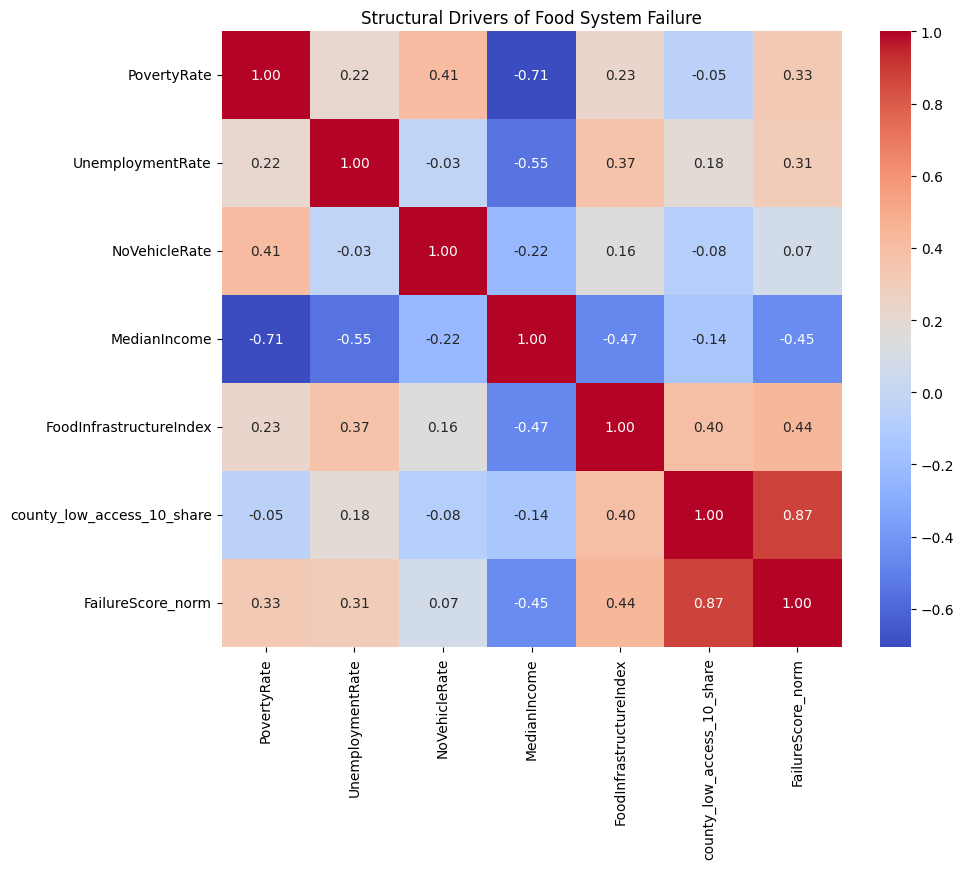

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

vars = [
"PovertyRate",
"UnemploymentRate",
"NoVehicleRate",
"MedianIncome",
"FoodInfrastructureIndex",
"county_low_access_10_share",
"FailureScore_norm"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    merged_all[vars].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Structural Drivers of Food System Failure")

plt.show()

In [198]:
state_metrics = merged_all.groupby("State").agg({
    "FoodInfrastructureIndex": "mean",
    "county_low_access_10_share": "mean",
    "StructuralRisk_norm": "mean",
    "PolicyPriority": "mean"
}).reset_index()

In [199]:
state_abbrev = {
"Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR",
"California":"CA","Colorado":"CO","Connecticut":"CT","Delaware":"DE",
"Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID",
"Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
"Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
"Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
"Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
"New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
"North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
"Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
"South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT",
"Vermont":"VT","Virginia":"VA","Washington":"WA","West Virginia":"WV",
"Wisconsin":"WI","Wyoming":"WY"
}

state_metrics["state_code"] = state_metrics["State"].map(state_abbrev)

In [200]:
import plotly.express as px

fig = px.choropleth(
    state_metrics,
    locations="state_code",
    locationmode="USA-states",
    color="county_low_access_10_share",
    scope="usa",
    color_continuous_scale="Reds",
    hover_data={
        "State": True,
        "FoodInfrastructureIndex": ':.2f',
        "StructuralRisk_norm": ':.2f'
    }
)

fig.update_layout(
    title="State-Level Food Access Barriers in the United States",
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

In [201]:
fig = px.choropleth(
    state_metrics,
    locations="state_code",
    locationmode="USA-states",
    color="StructuralRisk_norm",
    scope="usa",
    color_continuous_scale="OrRd",
    title="State-Level Structural Vulnerability"
)

fig.show()

In [202]:
fig = px.choropleth(
    state_metrics,
    locations="state_code",
    locationmode="USA-states",
    color="PolicyPriority",
    scope="usa",
    color_continuous_scale="YlOrRd",
    title="States with Highest Food Policy Priority"
)

fig.show()

In [204]:
merged_all.to_csv(
"/content/drive/MyDrive/data mining/cleaned/final_food_system_123.csv",
index=False
)